<a href="https://colab.research.google.com/github/SudiWafula/ARABLE-PRODUCTION-ON-CEREALS-IN-IRELAND/blob/main/Copy_of_eurusdLSTM_FX_Training_Colab_Readymodel5minupdate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ✅ Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ✅ Step 3: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import seaborn as sns
import joblib
from scipy.stats import linregress

In [ ]:
# ✅ Step 2: Set File Paths
DATA_PATH = '/content/drive/MyDrive/FX STORE DATA FOLDER/eurusdfiveupdate.csv'
MODEL_SAVE_PATH = '/content/drive/MyDrive/FX STORE DATA FOLDER/eurusdupdatedbest_lstm_model.keras'
SCALER_SAVE_PATH = '/content/drive/MyDrive/FX STORE DATA FOLDER/eurusdupdatedminmax_scaler.save'

In [ ]:
df = pd.read_csv(DATA_PATH)

# Print shape info
print(f"✅ Dataset loaded successfully.")
print(f"🔍 Number of rows: {df.shape[0]}")
print(f"🔍 Number of columns: {df.shape[1]}")
print(f"\n📝 First 5 rows:")
print(df.head())

✅ Dataset loaded successfully.
🔍 Number of rows: 98152
🔍 Number of columns: 8

📝 First 5 rows:
                        time     open     high      low    close  tick_volume  \
0  2024-03-05 17:55:00+00:00  1.08720  1.08725  1.08700  1.08714          367   
1  2024-03-05 18:00:00+00:00  1.08714  1.08719  1.08655  1.08655          587   
2  2024-03-05 18:05:00+00:00  1.08656  1.08673  1.08631  1.08633          463   
3  2024-03-05 18:10:00+00:00  1.08633  1.08640  1.08607  1.08640          480   
4  2024-03-05 18:15:00+00:00  1.08641  1.08651  1.08637  1.08642          297   

   spread  real_volume  
0      10            0  
1      10            0  
2      10            0  
3      10            0  
4      10            0  


In [ ]:
# Rename tick_volume to volume for compatibility
df.rename(columns={'tick_volume': 'volume'}, inplace=True)

# Optional: drop columns you won't use (if needed)
# df.drop(columns=['real_volume', 'spread'], inplace=True)

# Confirm the change
print("✅ Volume column renamed:")
print(df[['volume']].head())


✅ Volume column renamed:
   volume
0     367
1     587
2     463
3     480
4     297


In [ ]:
import numpy as np
from scipy.stats import linregress

# Utility to calculate slope of rolling window (used for trend)
def calc_slope(series):
    x = np.arange(len(series))
    slope, _, _, _, _ = linregress(x, series)
    return slope

# Enhanced Feature Engineering
def feature_engineering(df):
    df = df.copy()

    # === 1. Basic Features ===
    df['log_return'] = np.log(df['close'] / df['close'].shift(1))
    df['volatility'] = df['log_return'].rolling(window=20).std()
    df['range'] = df['high'] - df['low']
    df['price_pos'] = (df['close'] - df['low']) / (df['high'] - df['low'] + 1e-9)
    df['ohlc_avg'] = (df['open'] + df['high'] + df['low'] + df['close']) / 4

    # === 2. Volume-Based Features ===
    df['volume_change'] = df['volume'] / df['volume'].shift(1)
    df['volume_rolling'] = df['volume'].rolling(window=10).mean()
    df['volume_ratio'] = df['volume'] / (df['volume_rolling'] + 1e-9)

    # === 3. Momentum / Trend Features ===
    df['return_3'] = np.log(df['close'] / df['close'].shift(3))
    df['return_5'] = np.log(df['close'] / df['close'].shift(5))
    df['slope_ohlc_10'] = df['ohlc_avg'].rolling(window=10).apply(calc_slope, raw=False)

    # === 4. Relative Position Features ===
    df['ma_10'] = df['close'].rolling(10).mean()
    df['distance_from_ma'] = df['close'] - df['ma_10']

    df['zscore_close'] = (
        (df['close'] - df['close'].rolling(20).mean()) /
        (df['close'].rolling(20).std() + 1e-9)
    )

    # Drop NaNs introduced by rolling
    df = df.dropna().reset_index(drop=True)
    return df


In [ ]:
# Apply the feature engineering function to your data
df_features = feature_engineering(df)

# Preview the new dataset with features
print(f"✅ New dataset shape: {df_features.shape}")
print("📌 First 5 rows with new features:")
print(df_features.head())


✅ New dataset shape: (98132, 22)
📌 First 5 rows with new features:
                        time     open     high      low    close  volume  \
0  2024-03-05 19:35:00+00:00  1.08610  1.08619  1.08587  1.08589     195   
1  2024-03-05 19:40:00+00:00  1.08589  1.08600  1.08577  1.08587     260   
2  2024-03-05 19:45:00+00:00  1.08587  1.08609  1.08584  1.08599     180   
3  2024-03-05 19:50:00+00:00  1.08598  1.08602  1.08583  1.08600     135   
4  2024-03-05 19:55:00+00:00  1.08600  1.08608  1.08591  1.08598     227   

   spread  real_volume  log_return  volatility  ...  ohlc_avg  volume_change  \
0      10            0   -0.000193    0.000194  ...  1.086013       0.855263   
1      10            0   -0.000018    0.000157  ...  1.085883       1.333333   
2      10            0    0.000111    0.000154  ...  1.085947       0.692308   
3      10            0    0.000009    0.000153  ...  1.085957       0.750000   
4      10            0   -0.000018    0.000153  ...  1.085993       1.681481

In [ ]:
# Save feature-enhanced dataset to Google Drive
output_path = "/content/drive/MyDrive/FX STORE DATA FOLDER/eurusdfive_features.csv"
df_features.to_csv(output_path, index=False)

print(f"✅ Feature-enhanced dataset saved to: {output_path}")


✅ Feature-enhanced dataset saved to: /content/drive/MyDrive/FX STORE DATA FOLDER/eurusdfive_features.csv


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Define the feature columns used for modeling
FEATURE_COLUMNS = [
    'log_return', 'volatility', 'range', 'price_pos', 'ohlc_avg',
    'volume_change', 'volume_ratio', 'return_3', 'return_5',
    'slope_ohlc_10', 'distance_from_ma', 'zscore_close'
]

# Path to save the scaler
SCALER_SAVE_PATH = '/content/drive/MyDrive/FX STORE DATA FOLDER/eurusdupdatedminmax_scaler.save'

# Fit scaler on these columns
scaler = MinMaxScaler()
scaler.fit(df_features[FEATURE_COLUMNS])

# Save the fitted scaler for reuse
joblib.dump(scaler, SCALER_SAVE_PATH)

print(f"✅ Scaler fitted and saved. Feature shape: {df_features[FEATURE_COLUMNS].shape}")


✅ Scaler fitted and saved. Feature shape: (98132, 12)


In [ ]:
import numpy as np

SEQUENCE_LENGTH = 40
THRESHOLD = 0.0003  # 3 pips

def prepare_sequences(df, scaler, sequence_length=40, threshold=0.0003):
    # Scale selected features
    df_scaled = pd.DataFrame(scaler.transform(df[FEATURE_COLUMNS]), columns=FEATURE_COLUMNS)

    X, y, keep_idx = [], [], []

    for i in range(sequence_length + 1, len(df_scaled)):
        prev_avg = df['ohlc_avg'].iloc[i - 2]
        curr_avg = df['ohlc_avg'].iloc[i - 1]
        change = (curr_avg - prev_avg) / prev_avg

        if change > threshold:
            label = 1  # BUY
        elif change < -threshold:
            label = 0  # SELL
        else:
            continue  # skip flat moves

        X.append(df_scaled.iloc[i - sequence_length - 1:i - 1].values)
        y.append(label)
        keep_idx.append(i - 1)

    df_meta = df.iloc[keep_idx].reset_index(drop=True)
    return np.array(X), np.array(y), df_meta

# Run the function
X, y, df_meta = prepare_sequences(df_features, scaler)

print(f"✅ Sequence creation complete.")
print(f"X shape: {X.shape}, y shape: {y.shape}, Meta rows: {df_meta.shape[0]}")


✅ Sequence creation complete.
X shape: (9500, 40, 12), y shape: (9500,), Meta rows: 9500


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

def build_and_train_lstm(X, y, epochs=20, batch_size=32):
    model = Sequential()
    model.add(LSTM(units=64, input_shape=(X.shape[1], X.shape[2])))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))  # Binary classification

    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

    early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

    history = model.fit(X, y, epochs=epochs, batch_size=batch_size, verbose=1, callbacks=[early_stop])

    return model, history

# Train the model
model, history = build_and_train_lstm(X, y)

# Optionally save model
MODEL_PATH = '/content/drive/MyDrive/FX STORE DATA FOLDER/eurusdupdatedbest_lstm_model.keras'
model.save(MODEL_PATH)

print(f"✅ Model trained and saved to: {MODEL_PATH}")


Epoch 1/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.6662 - loss: 0.6339
Epoch 2/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9099 - loss: 0.3013
Epoch 3/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9121 - loss: 0.2466
Epoch 4/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9122 - loss: 0.2443
Epoch 5/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9053 - loss: 0.2576
Epoch 6/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9079 - loss: 0.2485
Epoch 7/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9096 - loss: 0.2462
Epoch 8/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9144 - loss: 0.2362
Epoch 9/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9139 - loss: 0.2349
Epoch 10/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9098 - loss: 0.2442
Epoch 11/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9116 - loss: 0.2401
Epoch 12/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 

297/297 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
✅ Classification Report:
              precision    recall  f1-score   support

        SELL       0.91      0.92      0.92      4723
         BUY       0.92      0.91      0.92      4777

    accuracy                           0.92      9500
   macro avg       0.92      0.92      0.92      9500
weighted avg       0.92      0.92      0.92      9500



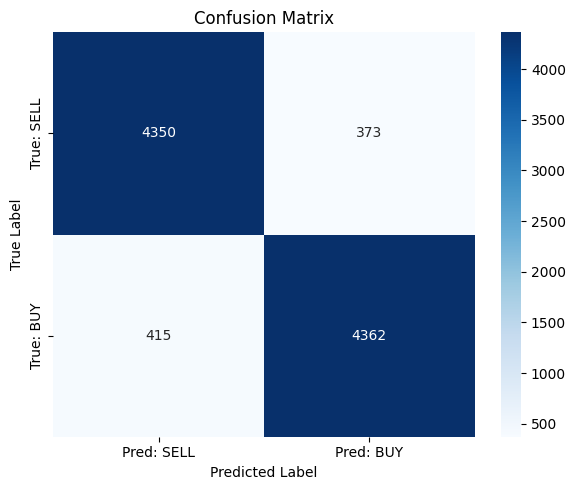

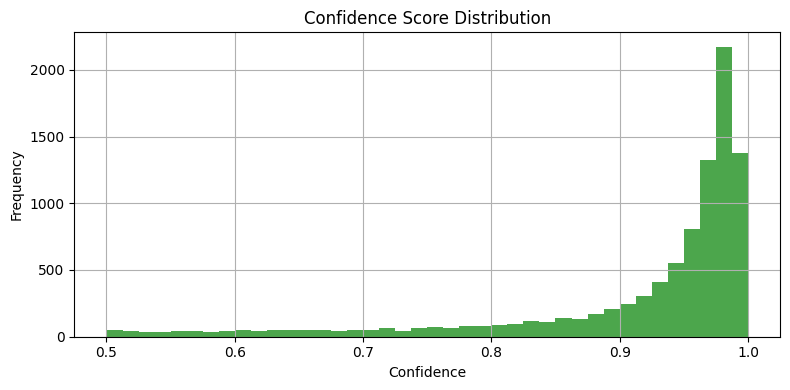

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# === Predict on training sequences ===
y_probs = model.predict(X).flatten()
y_preds = (y_probs > 0.5).astype(int)

# === Evaluation Metrics ===
print("✅ Classification Report:")
print(classification_report(y, y_preds, target_names=["SELL", "BUY"]))

# === Confusion Matrix ===
conf_matrix = confusion_matrix(y, y_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred: SELL", "Pred: BUY"], yticklabels=["True: SELL", "True: BUY"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# === Confidence Score Distribution ===
confidence_scores = np.where(y_preds == 1, y_probs, 1 - y_probs)

plt.figure(figsize=(8, 4))
plt.hist(confidence_scores, bins=40, alpha=0.7, color="green")
plt.title("Confidence Score Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional: Attach predictions to df_meta for later signal analysis
df_eval = df_meta.copy()
df_eval['y_true'] = y
df_eval['y_pred'] = y_preds
df_eval['confidence'] = y_probs
df_eval['confidence_score'] = confidence_scores


In [ ]:
def generate_signals(df_eval, delta_threshold=2.0, confidence_threshold=0.8):
    df = df_eval.copy()

    # === Signal Translation ===
    df['signal'] = df['y_pred'].map({1: 'BUY', 0: 'SELL'})
    df['actual'] = df['y_true'].map({1: 'BUY', 0: 'SELL'})
    df['correct'] = df['y_pred'] == df['y_true']

    # === Delta in Pips (used for signal strength evaluation)
    df['delta_pips'] = (df['close'].shift(-1) - df['close']) * 10000
    df['strong_delta'] = df['delta_pips'].abs() >= delta_threshold

    # === Confidence Score: Reflect certainty for each signal
    df['confidence_score'] = np.where(
        df['signal'] == 'BUY',
        df['confidence'],         # If BUY, use raw probability
        1 - df['confidence']      # If SELL, invert probability
    )

    # === Assign Tiers Based on Confidence
    def assign_tier(conf):
        if conf >= 0.85:
            return 'Tier 1 (Very High)'
        elif conf >= 0.70:
            return 'Tier 2 (High)'
        elif conf >= 0.50:
            return 'Tier 3 (Moderate)'
        else:
            return 'Tier 4 (Low)'

    df['signal_tier'] = df['confidence_score'].apply(assign_tier)

    # === Profit Simulation: Binary payout (win = 0.8, loss = -1.0)
    df['profit'] = df['correct'].apply(lambda x: 0.8 if x else -1.0)
    df['equity'] = df['profit'].cumsum()

    # === Filter Realistic High-Confidence Signals
    filtered = df[
        (df['confidence_score'] >= confidence_threshold) &
        (df['strong_delta'])
    ].copy()

    filtered['equity'] = filtered['profit'].cumsum()

    # === Plot Filtered Signal Equity Curve
    plt.figure(figsize=(10, 5))
    plt.plot(filtered['equity'], label='Filtered Equity Curve', color='orange')
    plt.title("Cumulative Profit on Filtered High-Confidence Signals")
    plt.xlabel("Trade Index")
    plt.ylabel("Profit")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # === Summary Output
    total = len(filtered)
    wins = filtered['profit'].gt(0).sum()
    losses = filtered['profit'].lt(0).sum()
    win_rate = round((wins / total) * 100, 2) if total else 0.0
    total_profit = round(filtered['profit'].sum(), 2)

    print(f"✅ Filtered Trades: {total}")
    print(f"✔️ Wins: {wins}, ❌ Losses: {losses}")
    print(f"📈 Win Rate: {win_rate}%")
    print(f"💰 Total Profit: {total_profit} units")

    return df, filtered


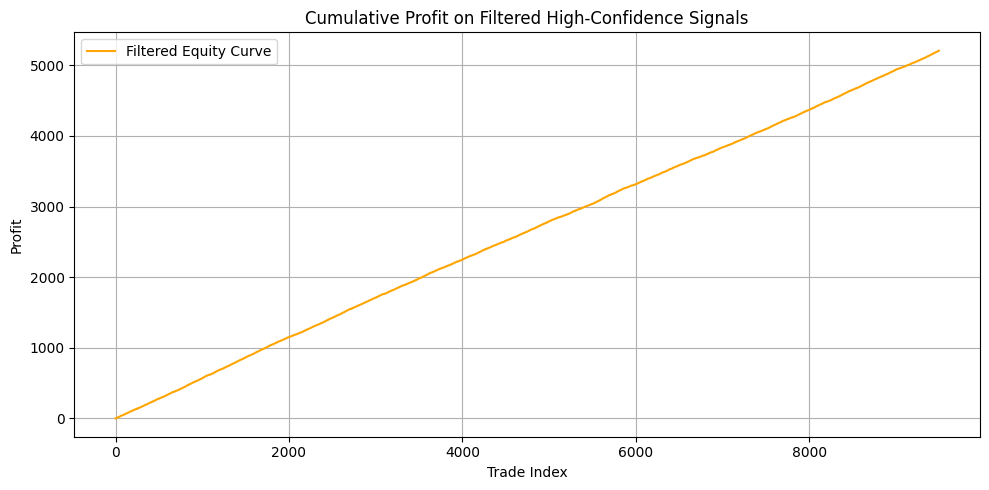

✅ Filtered Trades: 7137
✔️ Wins: 6857, ❌ Losses: 280
📈 Win Rate: 96.08%
💰 Total Profit: 5205.6 units


In [ ]:
# Generate signals + simulate trading
df_signals, df_filtered_signals = generate_signals(df_eval)
